In [5]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]

data_folder="../Data/"

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, saveresults_pickle, select_rows
from BCI_Library import sort_rank, compute_welch_select_regions, extract_features_from_spectra_more_bands,compute_welch
from BCI_Library import plot_hist2d_selected_regions_folds, select_regions_MyCriteria, select_regions_Cohen_effect_size, select_regions_MyCriteria2

"""# new_row = {
#     "ROIs": [selected_regions_EEG],
#     "NROIs":[25]
#     "DataType": ["EEG"],
#     "freqs_band": [((4,8),(8,12),(12,30))],  
#     "subject": [subject_index],
#     "Classifier": ["LDA"],
#     "Performance": [training[0]],
#     "Features": ["PowerSpectra - MeanMax band"],
#     "Comments": ["-"],
#     "Date": [today],
#     "Personalized_Freq_Range" = False,
# }"""


'# new_row = {\n#     "ROIs": [selected_regions_EEG],\n#     "NROIs":[25]\n#     "DataType": ["EEG"],\n#     "freqs_band": [((4,8),(8,12),(12,30))],  \n#     "subject": [subject_index],\n#     "Classifier": ["LDA"],\n#     "Performance": [training[0]],\n#     "Features": ["PowerSpectra - MeanMax band"],\n#     "Comments": ["-"],\n#     "Date": [today],\n#     "Personalized_Freq_Range" = False,\n# }'

# Perform Selections

## MyCriteria - Based on MaxDiff Rest-MI
- I am "averaging" (selecting) on frequency bins
- I am averaging among trials

This is why MyCriteria is more robust with respect to Multi T-Test on whole Power Spectra 


In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
    dizio[f"ROIs_global"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch_select_regions(data_2_MI, data_2_Rest, sfreq, important_regions=[], select_regions=False,
                                                        kargs_welch={"fmin":8, "fmax":30})

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
            regions_selected = select_regions_MyCriteria(wpsdMI=WMI[selected_idx[np.where(selected_idx<len(WMI))]], 
                                                            wpsdRest=WRe[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI)], 
                                                            important_regions=[], nbest_regions=quanteroi)
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple(regions_selected))

        ########### GLOBAL no folds #############
        regions_selected = select_regions_MyCriteria(wpsdMI=WMI, wpsdRest=WRe, important_regions=[], nbest_regions=quanteroi)
        dizio[f"ROIs_global"].append(tuple(regions_selected))

    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MyCriteria_{DataType}_among_{n_folds}_folds_training_selected_freq_8_30_v2.pkl")




100%|██████████| 20/20 [01:25<00:00,  4.26s/it]


In [15]:
import pandas as pd
filepath = "../Results/RegionSelection/Selected_regions"
pandadizio=pd.read_pickle(filepath+f"_MyCriteria_EEG_among_5_folds_training_selected_freq_8_30.pkl")
pandadizio

,Subject,ROIs_fold_1,ROIs_fold_2,ROIs_fold_3,ROIs_fold_4,ROIs_fold_5,ROIs_global
0,0,"(23, 15, 51, 14, 50, 59, 35, 58, 17, 22, 42, 6...","(23, 14, 22, 15, 50, 42, 58, 6, 17, 51, 35, 7,...","(23, 15, 51, 17, 14, 59, 22, 58, 42, 50, 35, 6...","(23, 15, 14, 51, 17, 22, 59, 50, 58, 35, 6, 42...","(23, 15, 14, 22, 17, 35, 42, 50, 6, 58, 51, 27...","(23, 15, 14, 22, 17, 51, 50, 58, 35, 42, 59, 6..."
1,1,"(67, 61, 43, 59, 42, 51, 17, 26, 32, 50, 19, 7...","(67, 61, 43, 59, 42, 51, 26, 7, 17, 1, 30, 62,...","(67, 61, 43, 59, 1, 51, 17, 32, 50, 7, 42, 20,...","(67, 61, 43, 59, 42, 17, 1, 26, 51, 21, 32, 62...","(67, 61, 43, 59, 42, 32, 51, 26, 1, 17, 7, 20,...","(67, 61, 43, 59, 42, 51, 17, 1, 26, 32, 7, 50,..."
2,2,"(42, 14, 43, 26, 23, 27, 22, 6, 48, 21, 4, 15,...","(42, 14, 43, 26, 23, 48, 27, 6, 22, 4, 10, 11,...","(14, 42, 23, 43, 26, 48, 4, 27, 22, 10, 11, 21...","(42, 23, 43, 14, 26, 27, 22, 6, 21, 48, 20, 32...","(42, 43, 14, 23, 6, 27, 48, 26, 32, 4, 22, 21,...","(42, 14, 43, 23, 26, 27, 48, 6, 22, 4, 21, 32,..."
3,3,"(7, 22, 23, 15, 51, 50, 59, 45, 43, 6, 32, 33,...","(7, 22, 23, 15, 51, 32, 50, 59, 45, 33, 43, 6,...","(7, 22, 23, 32, 43, 15, 56, 51, 33, 50, 14, 62...","(7, 22, 23, 15, 51, 50, 59, 43, 14, 33, 6, 48,...","(7, 22, 23, 51, 15, 50, 43, 14, 59, 32, 45, 6,...","(7, 22, 23, 15, 51, 50, 43, 32, 59, 33, 14, 45..."
4,4,"(16, 30, 22, 10, 7, 12, 48, 57, 32, 56, 44, 4,...","(22, 7, 16, 30, 10, 57, 48, 32, 56, 47, 12, 44...","(7, 22, 16, 30, 62, 48, 64, 57, 12, 4, 14, 44,...","(16, 30, 10, 48, 44, 4, 12, 22, 47, 55, 64, 32...","(22, 16, 30, 7, 57, 48, 58, 12, 62, 4, 32, 44,...","(16, 22, 30, 7, 10, 48, 57, 12, 4, 32, 44, 47,..."
5,5,"(7, 6, 4, 27, 33, 43, 59, 46, 56, 20, 50, 51, ...","(4, 7, 6, 57, 38, 33, 23, 27, 59, 24, 43, 46, ...","(4, 6, 46, 7, 43, 27, 38, 22, 23, 24, 20, 57, ...","(4, 6, 33, 43, 7, 46, 40, 22, 27, 23, 20, 58, ...","(6, 7, 4, 59, 33, 40, 43, 23, 27, 51, 46, 58, ...","(6, 4, 7, 33, 46, 43, 27, 23, 59, 20, 22, 38, ..."
6,6,"(0, 36, 48, 16, 30, 34, 25, 50, 56, 66, 29, 54...","(48, 0, 36, 16, 34, 14, 30, 25, 66, 12, 44, 29...","(36, 0, 48, 16, 34, 58, 45, 30, 54, 50, 14, 24...","(36, 0, 25, 12, 16, 48, 64, 54, 56, 14, 34, 50...","(0, 48, 16, 36, 56, 54, 34, 50, 12, 14, 30, 32...","(0, 36, 48, 16, 34, 30, 12, 50, 14, 54, 25, 56..."
7,7,"(7, 42, 43, 59, 27, 45, 6, 15, 22, 49, 14, 26,...","(7, 42, 43, 59, 27, 45, 22, 49, 6, 15, 32, 57,...","(59, 15, 7, 49, 45, 42, 43, 57, 5, 6, 53, 27, ...","(7, 42, 15, 43, 59, 6, 27, 22, 5, 57, 49, 14, ...","(7, 59, 15, 42, 43, 49, 45, 27, 6, 57, 5, 22, ...","(7, 42, 59, 43, 15, 49, 27, 6, 45, 22, 57, 5, ..."
8,8,"(15, 23, 26, 50, 27, 51, 34, 0, 35, 22, 17, 13...","(26, 27, 23, 15, 34, 35, 51, 50, 13, 0, 22, 17...","(15, 50, 51, 27, 26, 34, 23, 35, 58, 0, 17, 13...","(15, 51, 23, 50, 26, 27, 34, 0, 35, 22, 58, 17...","(15, 23, 50, 51, 26, 27, 34, 58, 35, 17, 7, 43...","(15, 26, 23, 51, 50, 27, 34, 35, 0, 22, 13, 17..."
9,9,"(65, 53, 55, 31, 32, 10, 52, 8, 11, 29, 23, 18...","(65, 55, 53, 10, 31, 11, 29, 52, 59, 18, 61, 2...","(65, 55, 10, 53, 59, 11, 31, 30, 23, 32, 51, 6...","(55, 53, 65, 10, 29, 11, 31, 59, 52, 51, 18, 2...","(55, 53, 65, 10, 52, 29, 11, 31, 18, 59, 61, 3...","(65, 55, 53, 10, 31, 11, 29, 52, 59, 18, 23, 6..."


Text(0.5, 1.0, 'fixed subject, ranking in 6 kfolds')

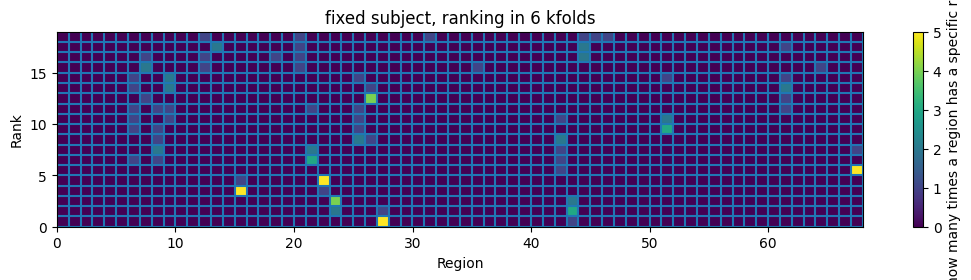

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap

subject=0
fino_a = 20

binx = np.arange(69)-0.001
biny = np.arange(fino_a)-0.001

rankings = []
for fold in range(1,len(pandadizio.keys())):
    rankings.append(list(pandadizio.iloc[subject,fold][:fino_a]))

rankings = np.array(rankings)
n_folds = rankings.shape[0]
plt.figure(figsize=(13,3.8*fino_a/30))
plt.hist2d(rankings.flatten(),np.tile(np.arange(fino_a), (n_folds,1)).flatten(),bins=(binx,biny))
#plt.hist2d(pandadizio.iloc[subject,1][:fino_a],range(fino_a),bins=(binx,biny))
plt.vlines(binx,0,fino_a)
plt.hlines(biny,0,68)
plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"fixed subject, ranking in {len(rankings)} kfolds")

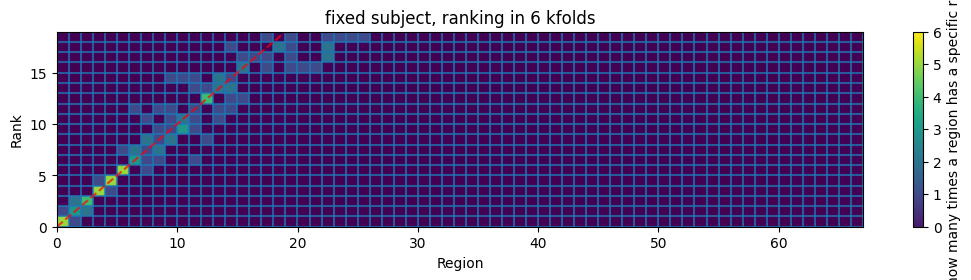

In [11]:
rankings_sorted, sorted_regions =  sort_rank(rankings)

plt.figure(figsize=(13,3.8*fino_a/30))

binx = np.arange(68)-0.001
biny = np.arange(fino_a)-0.001

mic = matplotlib.colormaps.get_cmap("viridis")
color0 = mic(0.)
other_colors = mic(np.linspace(0.07, 1., 1001))
colors = np.vstack([color0, other_colors])
cmap = ListedColormap(colors)

hist = plt.hist2d(
    rankings_sorted.flatten(),
    np.tile(np.arange(fino_a), (n_folds,1)).flatten(),
    bins=(binx, biny),
    cmap=cmap, vmin=0, vmax=len(rankings_sorted)  # ensures 6 discrete levels
)

coco = "C0"
plt.vlines(binx,0,fino_a,alpha=0.75,color=coco)
plt.hlines(biny,0,68,alpha=0.75,color=coco)

plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"fixed subject, ranking in {len(rankings_sorted)} kfolds")
plt.plot([0,68],[0,68],color="red",linestyle="--",alpha=0.7)

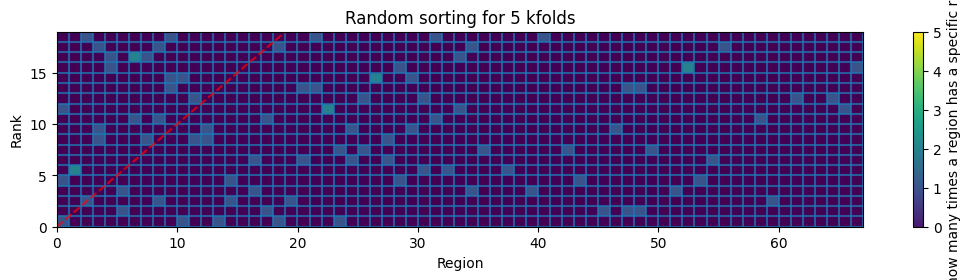

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from matplotlib.colors import ListedColormap

fino_a = 20
n_foldsSS = 5
random_rankings = np.array([np.random.permutation(np.arange(68)) for __ in range(n_foldsSS)])

rankings_random_sorted, sorted_random_regions =  sort_rank(random_rankings)

rankings_random_sorted = rankings_random_sorted[:,:fino_a]

plt.figure(figsize=(13,3.8*fino_a/30))

binx = np.arange(68)-0.001
biny = np.arange(fino_a)-0.001

mic = matplotlib.colormaps.get_cmap("viridis")
color0 = mic(0.)
other_colors = mic(np.linspace(0.07, 1., 1001))
colors = np.vstack([color0, other_colors])
cmap = ListedColormap(colors)

hist = plt.hist2d(
    rankings_random_sorted.flatten(),
    np.tile(np.arange(fino_a), (n_foldsSS,1)).flatten(),
    bins=(binx, biny),
    cmap=cmap, vmin=0, vmax=len(rankings_random_sorted)  # ensures 6 discrete levels
)

coco = "C0"
plt.vlines(binx,0,fino_a,alpha=0.75,color=coco)
plt.hlines(biny,0,68,alpha=0.75,color=coco)

plt.colorbar(label="how many times a region has a specific rank")
plt.xlabel("Region")
plt.ylabel("Rank")
plt.title(f"Random sorting for {len(rankings_random_sorted)} kfolds")
plt.plot([0,68],[0,68],color="red",linestyle="--",alpha=0.7)

## Multi T-test - on complete Power Spectra

In [ ]:
import pingouin as pg


import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

subject_index = 0
region = 33

data_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

sfreq = 250
pvalues=[]
power_MI, power_Rest, Freqs = compute_welch(data_MI,data_Rest)
for region in range(68):
    result = pg.multivariate_ttest(power_MI[:,region,:], power_Rest[:,region,:])
    pvalues.append(float(result.pval.values[0]))
# print(result)


In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=2
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

import math

round_sig = lambda x, sig=5: 0 if x == 0 else round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)

saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Pvalues_{fold+1}"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq)

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = val_idx
            pvalues = []
            for region in range(68):
                result = pg.multivariate_ttest(WMI[selected_idx[np.where(selected_idx<len(WMI))],region,:], 
                                               WRe[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI),region,:])
                pvalues.append(float(result.pval.values[0]))
            pvalues=np.array(pvalues)
            regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
            pvalues = pvalues[pvalues.argsort()]
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple([ int(_) for _ in regions_selected]))
            dizio[f"Pvalues_{fold_idx+1}"].append(tuple([round_sig(float(_),3) for _ in pvalues]))
    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MultiTtest_{DataType}_among_{n_folds}_folds_validation_selected_all_spectra.pkl")

100%|██████████| 20/20 [00:27<00:00,  1.35s/it]


## Multi T-test - on average of 2 bands

In [ ]:
import pingouin as pg


import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

subject_index = 2
region = 33

data_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

sfreq = 250
pvalues=[]
power_MI, power_Rest, Freqs = compute_welch(data_MI,data_Rest, kargs_welch={"fmin":8, "fmax":30})
# for region in range(68):
#     result = pg.multivariate_ttest(power_MI[:,region,:], power_Rest[:,region,:])
#     pvalues.append(float(result.pval.values[0]))
# print(result)


In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
import pingouin as pg

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

import math

round_sig = lambda x, sig=5: 0 if x == 0 else round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)

saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Pvalues_{fold+1}"] = []
    dizio[f"ROIs_global"] = []
    dizio[f"Pvalues_global"] = []

    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq)

        mean_alph = np.concatenate((WMI[:,:,np.where(FreqMI<12)].mean(axis=-1),WMI[:,:,np.where(FreqMI>=12)].mean(axis=-1)),axis=-1)
        mean_beta = np.concatenate((WRe[:,:,np.where(FreqMI<12)].mean(axis=-1),WRe[:,:,np.where(FreqMI>=12)].mean(axis=-1)),axis=-1)

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(mean_alph))] + [0 for __ in range(len(mean_beta))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
            pvalues = []
            for region in range(68):
                result = pg.multivariate_ttest(mean_alph[selected_idx[np.where(selected_idx<len(mean_alph))],region,:], 
                                               mean_beta[selected_idx[np.where(selected_idx>=len(mean_alph))]-len(mean_alph),region,:])
                pvalues.append(float(result.pval.values[0]))
            pvalues=np.array(pvalues)
            regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
            pvalues = pvalues[pvalues.argsort()]
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple([ int(_) for _ in regions_selected]))
            dizio[f"Pvalues_{fold_idx+1}"].append(tuple([round_sig(float(_),3) for _ in pvalues]))



        pvalues = []
        for region in range(68):
            result = pg.multivariate_ttest(mean_alph[:,region,:], mean_beta[:,region,:])
            pvalues.append(float(result.pval.values[0]))
        pvalues=np.array(pvalues)
        regions_selected=pvalues.argsort() # in base a chi ha il pvalue più piccolo
        pvalues = pvalues[pvalues.argsort()]
        dizio[f"ROIs_global"].append(tuple([ int(_) for _ in regions_selected]))
        dizio[f"Pvalues_global"].append(tuple([round_sig(float(_),3) for _ in pvalues]))




    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MultiTtest_on_mean_alpha_beta_{DataType}_among_{n_folds}_folds_training_selected.pkl")

100%|██████████| 20/20 [01:47<00:00,  5.36s/it]


## Cohen's d effect size

In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []
        dizio[f"Effect_size_fold_{fold+1}"] = []
    dizio[f"ROIs_global"] = []
    dizio[f"Effect_size_global"] = []

    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                            kargs_welch={"fmin":8, "fmax":30},
                                            #starttime=750,
                                            )

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
            regions_selected, effect_sizes = select_regions_Cohen_effect_size(wpsdMI=WMI[selected_idx[np.where(selected_idx<len(WMI))]], 
                                                            wpsdRest=WRe[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI)], 
                                                            important_regions=[], nbest_regions=quanteroi)
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple(regions_selected))
            dizio[f"Effect_size_fold_{fold_idx+1}"].append(tuple(effect_sizes))
        
        ################## GLOBAL selection, no fold ##################
        regions_selected, effect_sizes = select_regions_Cohen_effect_size(wpsdMI=WMI, 
                                                            wpsdRest=WRe, 
                                                            important_regions=[], nbest_regions=quanteroi)
        dizio[f"ROIs_global"].append(tuple(regions_selected))
        dizio[f"Effect_size_global"].append(tuple(effect_sizes))

        
    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_Choen_effect_size_{DataType}_among_{n_folds}_folds_training_selected_freq_8_30_v2.pkl")#_startingFrom3s.pkl")




100%|██████████| 20/20 [01:17<00:00,  3.85s/it]


In [ ]:
for subject_idx in range(5):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_Choen_effect_size_EEG_among_5_folds_training_selected_freq_8_30.pkl",
                                subject=subject_idx, num_best_selected=68, plot_sorted=True, 
                                figtitle=f"Choen_effect_sz_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                )


### Global selection - One selection for ALL subjects

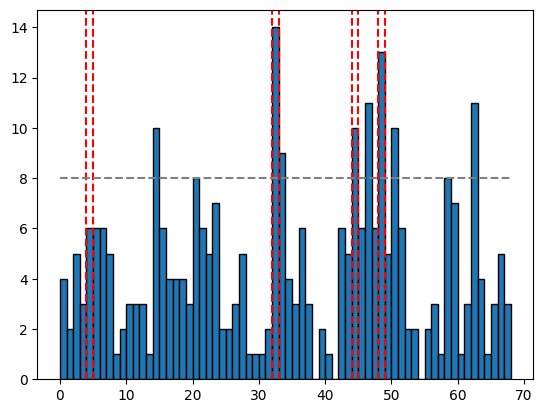

In [ ]:
RIVEDI TUTTO CHE ERO STANCO E FORSE HO FATTO UN CASINO (perche mi esce che )


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
DataType = "EEG"
filepath = "../Results/RegionSelection/Selected_regions"
fino_a = 15
soglias = {"EEG":{10:6,15:8},"MEG":{10:7,15:10}}
# soglias = {"EEG":{10:6,15:9},"MEG":{10:7,15:11}}

soglia = soglias[DataType][fino_a] # 7 per MEG,finoa10 - 10 per MEG,finoa15 -  6 per EEG,finoa10 - 8 per EEG,finoa15

regioni_selected = pd.read_pickle(filepath+f"_Choen_effect_size_{DataType}_among_5_folds_training_selected_freq_8_30.pkl")["ROIs_global"].to_numpy()


regioni_selected = np.array(regioni_selected.tolist())
"""how_many_times = {}
for regione in range(68):
    how_many_times[regione] = 0
for subject in range(20):
    for migiori_regioni in range(fino_a):
        regione_ora = regioni_selected[subject,migiori_regioni]
        how_many_times[regione_ora] +=  1 
"""

mean_position = {}
for regione in range(68):
    mean_position[regione] = 0
for subject in range(20):
    for position_selected in range(68):
        regione_ora = regioni_selected[subject,position_selected]

        mean_position[regione_ora] +=  position_selected / 20


counts,bins,graphics = plt.hist(regioni_selected[:,0:fino_a].flatten(),bins=np.arange(0,69), edgecolor="black")

regioni_finali = [i for i in range(len(counts)) if counts[i] >=  soglia ]

u = plt.ylim()
# evidenzio regioni importanti right
plt.vlines([4,5,32,33,44,45,48,49],0,20,colors="red",linestyles="--" )

plt.ylim(*u)
plt.hlines([soglia],0,68, colors="grey",linestyles="--")

# Quante per ognni soggetto tra le prime "fino_a" sono presenti tra quelle selezionate.
quante_per_soggetto = {}
for i in range(20):
    quante_per_soggetto[i] = 0

for subj_idx, regioni_subject in enumerate(regioni_selected[:,0:fino_a]):
    for regione in regioni_subject:
        if regione in regioni_finali:
            quante_per_soggetto[subj_idx]+=1


In [ ]:
# Quante per ognni soggetto tra le prime "fino_a" sono presenti tra quelle selezionate.
quante_per_soggetto

{0: 4,
 1: 2,
 2: 8,
 3: 6,
 4: 3,
 5: 5,
 6: 7,
 7: 7,
 8: 3,
 9: 6,
 10: 8,
 11: 4,
 12: 6,
 13: 3,
 14: 6,
 15: 6,
 16: 6,
 17: 5,
 18: 4,
 19: 5}

In [ ]:
# EEG
RIVEDI TUTTO CHE ERO STANCO E FORSE HO FATTO UN CASINO
print(regioni_finali, "\t", len(regioni_finali))

[14, 20, 32, 33, 44, 46, 48, 50, 58, 62] 	 10


In [ ]:
# MEG
RIVEDI TUTTO CHE ERO STANCO E FORSE HO FATTO UN CASINO
print(regioni_finali, "\t", len(regioni_finali))

[14, 32, 42, 43, 44, 46, 47, 48, 51, 62] 	 10


in comune tra EEG - MEG

14, 32, 44, 46, 48, 62

Text(0.5, 1.0, 'Dimostro che selezionare la media oppure in base al rank è simile')

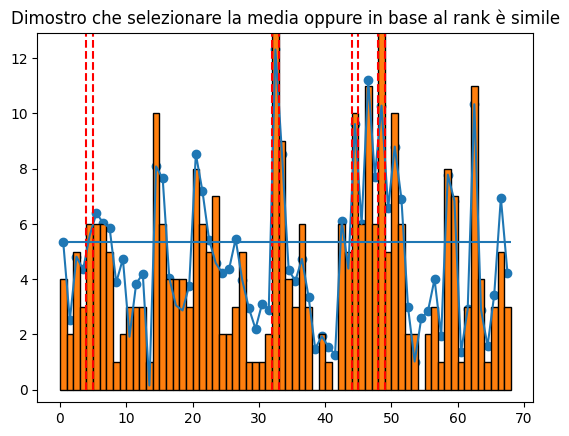

In [ ]:
RIVEDI TUTTO CHE ERO STANCO E FORSE HO FATTO UN CASINO
div = 3
piu = 48

plt.plot([_ + 0.5 for _ in mean_position.keys()],[(-_ +piu)/ div for _ in mean_position.values()])
plt.scatter([_ + 0.5 for _ in mean_position.keys()],[(-_ +piu)/ div for _ in mean_position.values()])
u = plt.ylim()
plt.vlines([4,5,32,33,44,45,48,49],0,20,colors="red",linestyles="--" )

plt.ylim(*u)
plt.hlines([(-32+piu)/div],0,68)
plt.hist(regioni_selected[:,0:fino_a].flatten(),bins=np.arange(0,69), edgecolor="black")
plt.title("Dimostro che selezionare la media oppure in base al rank è simile")

### Verify Frequency bin selection

In [5]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
from BCI_Library import cohens_d_per_columm

n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"
cohen_s = {"EEG":[]}
for DataType in ["EEG"]:

    for subject_index in tqdm.tqdm(range(20)):
        cohen_s[DataType].append([])
        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch(data_2_MI, data_2_Rest, sfreq,
                                            kargs_welch={"fmin":8, "fmax":30},
                                            #starttime=750,
                                            )

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            cohen_s[DataType][-1].append([])
            # already computed spectra
            selected_idx = train_idx
            wpsdMI=WMI[selected_idx[np.where(selected_idx<len(WMI))]]
            wpsdRest=WRe[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI)]
            for roi in range(quanteroi):
                wpsdMI_1ROI =wpsdMI[:,roi,:]
                wpsdRest_1ROI =wpsdRest[:,roi,:]

                cohen_s[DataType][-1][-1].append(cohens_d_per_columm(wpsdMI_1ROI,wpsdRest_1ROI, return_all=True))
    cohen_s[DataType] = np.array(cohen_s[DataType])
# choens_s["EEG"] shape: (sub,fold,roi,freq_bins) (20,5,68,27)



100%|██████████| 20/20 [01:16<00:00,  3.81s/it]


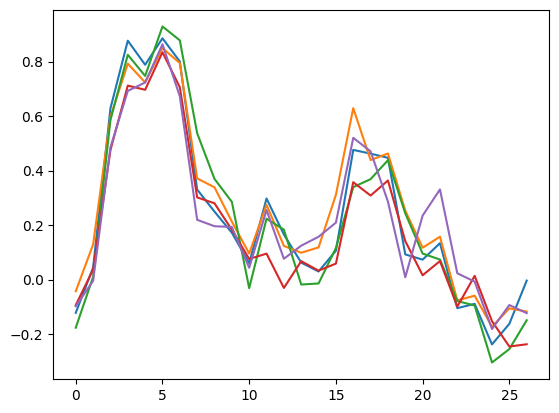

In [29]:
import matplotlib.pyplot as plt
sbj = 0; roi = 11
for i in cohen_s["EEG"][sbj,:,roi]:
    plt.plot(i)

In [13]:
sbj = 0
cohen_s[DataType][sbj].shape

(5, 68, 27)

In [31]:
sbj = 19
ch_sbj_meafold = cohen_s[DataType][sbj].mean(axis=0)
vals = ch_sbj_meafold.max(axis=1)
best_rois = np.argsort(vals)[-20:] [::-1]
np.argmax(ch_sbj_meafold[best_rois],axis=-1)

array([18,  4,  4, 18,  4,  5, 14,  4,  5,  4,  3,  3,  2,  4,  3, 14,  3,
       12,  3,  4])

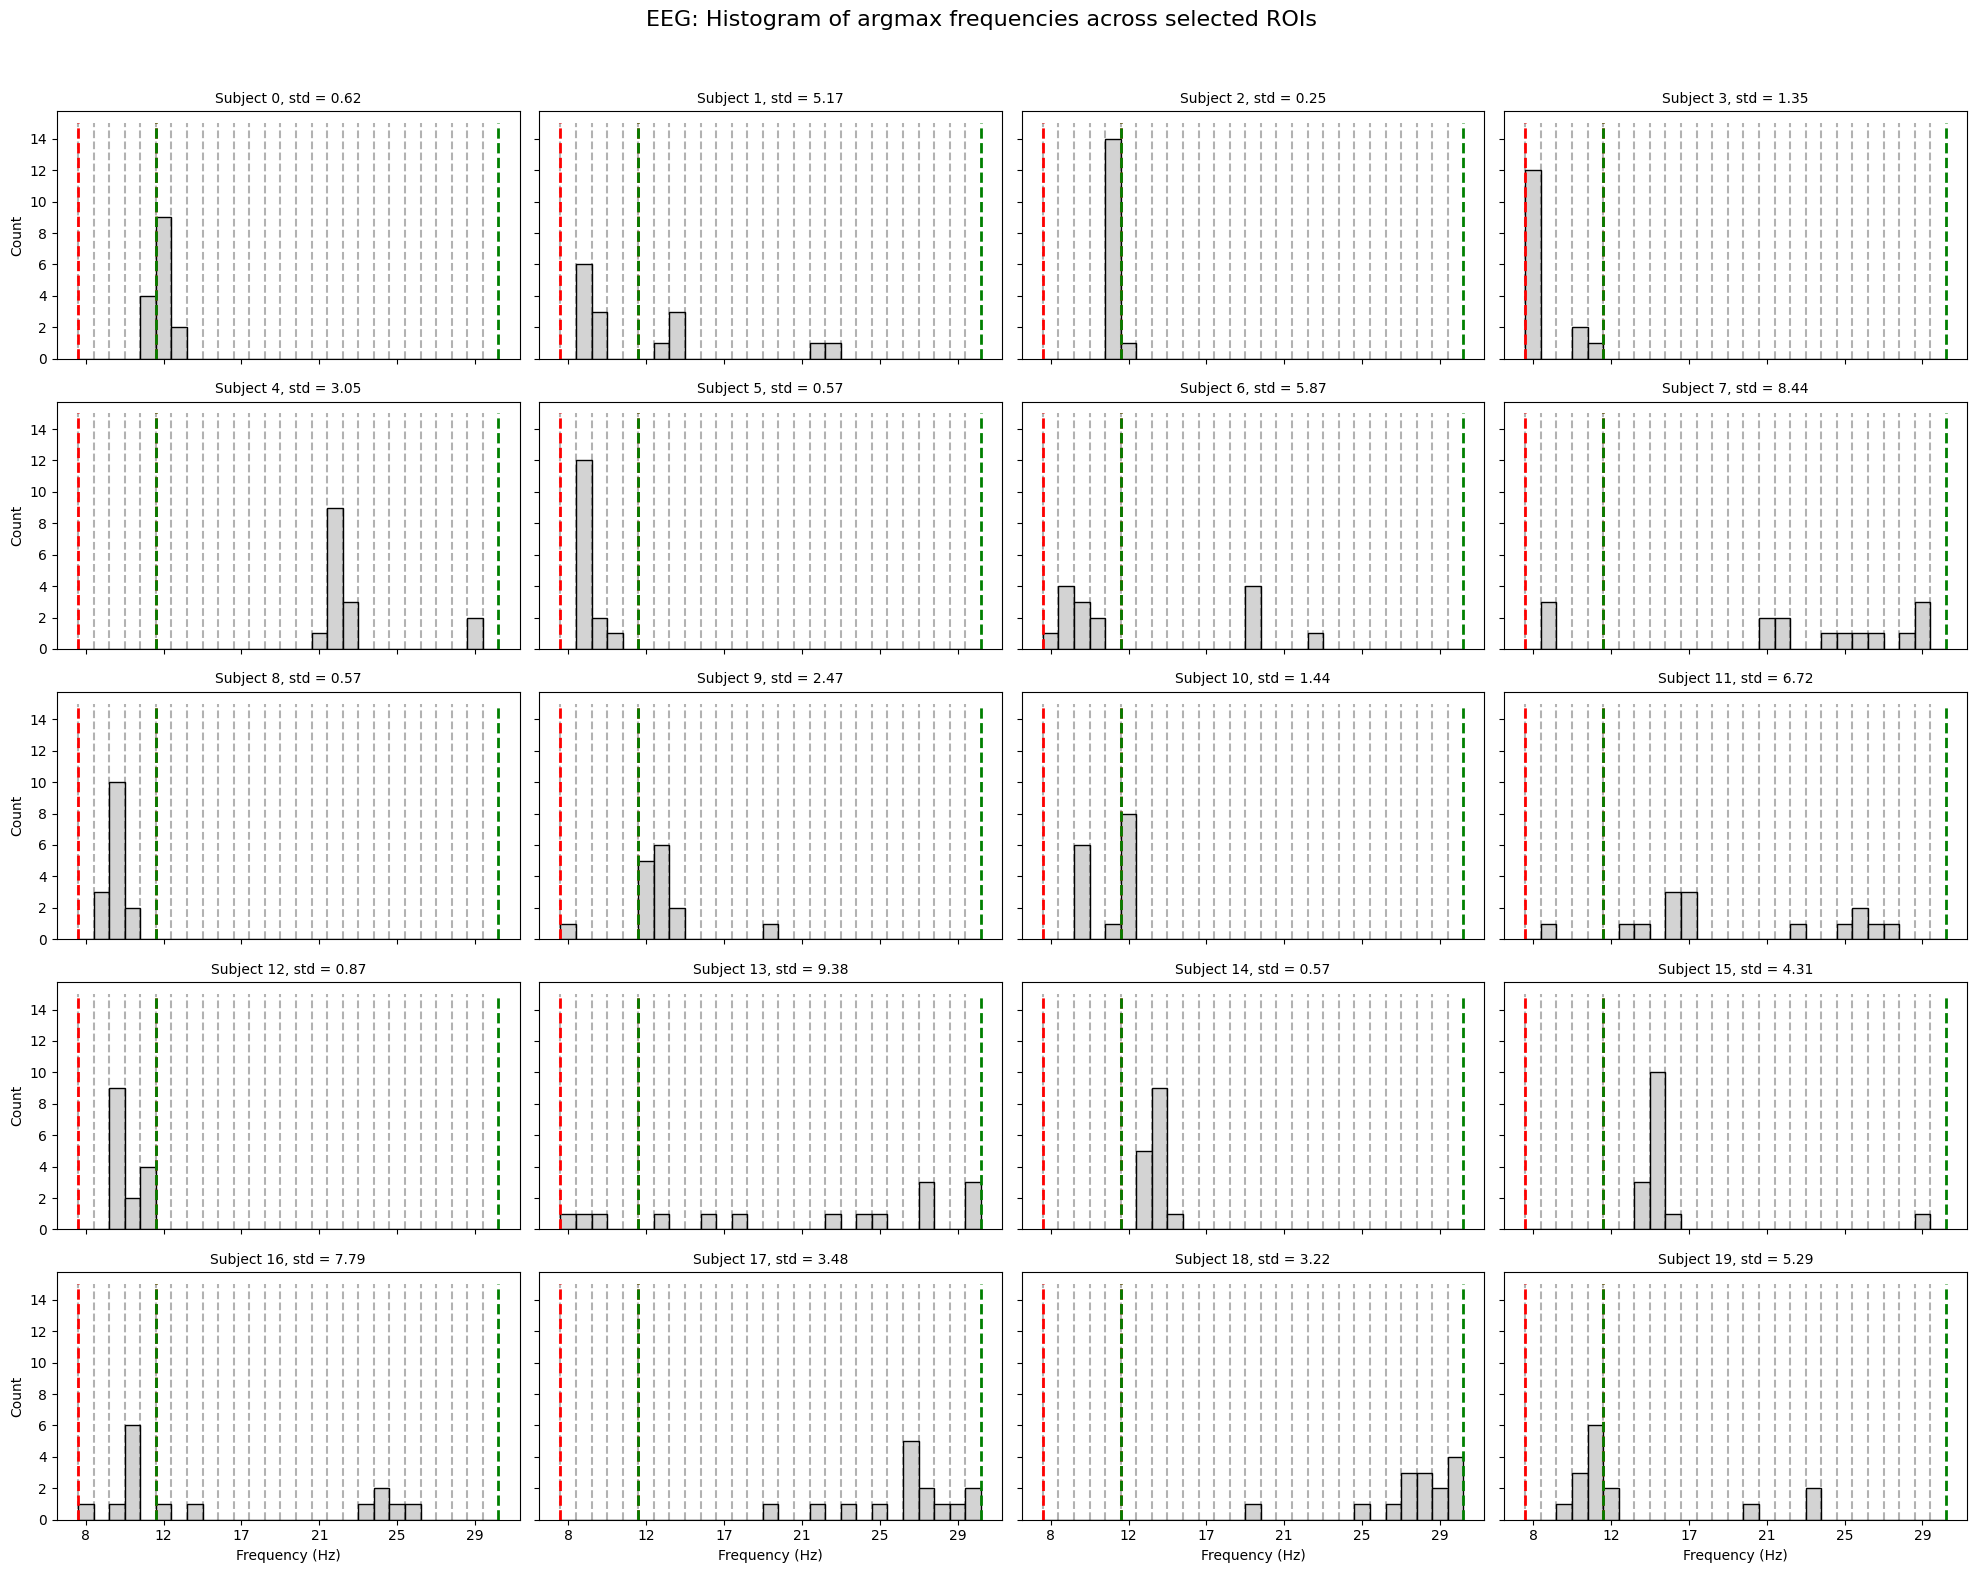

In [68]:
import numpy as np
import matplotlib.pyplot as plt

n_subjects = 20
n_best_rois = 15
DataType = "EEG"   # "MEG"

n_rows, n_cols = 5, 4

# Frequency bands (example)
min_freqs = [8, 12]
max_freqs = [12, 30]
band_colors = ["red", "green"]

tmp = cohen_s[DataType][0].mean(axis=0)
n_freqs = tmp.shape[-1]

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, 16),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

for sbj in range(n_subjects):

    ax = axes[sbj]
    ch_sbj_meafold = cohen_s[DataType][sbj].mean(axis=0)
    vals = ch_sbj_meafold.max(axis=1)
    best_rois = np.argsort(vals)[-n_best_rois:][::-1]
    i_freq_max = np.argmax(
        ch_sbj_meafold[best_rois],
        axis=-1
    )


    ax.hist(
        i_freq_max,
        bins=np.arange(n_freqs + 1) - 0.5,
        color="lightgray",
        edgecolor="black"
    )

    # grid lines
    ax.vlines(
        np.arange(n_freqs) - 0.5,
        0,n_best_rois,
        colors="black",
        linestyles="--",
        alpha=0.3
    )

    # FREQUENCY BANDS
    for i, color in enumerate(band_colors):
        start_idx = np.where(FreqMI >= min_freqs[i])[0][0]
        end_idx   = np.where(FreqMI <= max_freqs[i])[0][-1]

        ax.vlines(
            [start_idx - 0.5, end_idx + 0.5],
            0,n_best_rois,
            colors=color,
            linestyles="--",
            linewidth=2
        )


    std_ = np.std(i_freq_max)
    ax.set_title(f"Subject {sbj}, std = {std_:.2f}", fontsize=10)

for ax in axes[-n_cols:]:
    ax.set_xlabel("Frequency (Hz)")
    ticks = [0, 5, 10, 15, 20, 25]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{_:.0f}" for _ in FreqMI[[0, 5, 10, 15, 20, 25]]])


for ax in axes[::n_cols]:
    ax.set_ylabel("Count")



plt.suptitle(
    f"{DataType}: Histogram of argmax frequencies across selected ROIs",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [64]:
[f"{_:.2f}" for _ in FreqMI[[0,5,10,15,20,25]]]

['8.33', '12.50', '16.67', '20.83', '25.00', '29.17']

## MyCriteria2

In [ ]:
from sklearn.model_selection import StratifiedKFold 
import numpy as np
import pandas as pd
from datetime import date
import tqdm
n_folds=5
kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=224)
today = date.today()
sfreq = 250

quanteroi = 68
saveresults = True
filepath = "../Results/RegionSelection/Selected_regions"

for DataType in ["EEG","MEG"]:
    dizio = {"Subject":[]}
    for fold in range(n_folds):
        dizio[f"ROIs_fold_{fold+1}"] = []


    for subject_index in tqdm.tqdm(range(20)):

        data_2_MI = read_subject(data_folder, DataType, "MI", subject_index, verbose=False)
        data_2_Rest =read_subject(data_folder, DataType, "Baseline", subject_index, verbose=False)
        WMI, WRe, FreqMI = compute_welch_select_regions(data_2_MI, data_2_Rest, sfreq, important_regions=[], select_regions=False,
                                                        kargs_welch={"fmin":8, "fmax":30})

        dizio["Subject"].append(subject_index)

        labels = [1 for __ in range(len(WMI))] + [0 for __ in range(len(WRe))] 
         
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split([0 for _ in range(len(labels))], labels)):
            # already computed spectra
            selected_idx = train_idx
            regions_selected = select_regions_MyCriteria2(wpsdMI=WMI[selected_idx[np.where(selected_idx<len(WMI))]], 
                                                            wpsdRest=WRe[selected_idx[np.where(selected_idx>=len(WMI))]-len(WMI)], 
                                                            important_regions=[], nbest_regions=quanteroi)
            dizio[f"ROIs_fold_{fold_idx+1}"].append(tuple(regions_selected))
    pandadizio = pd.DataFrame.from_dict(dizio)
    #pandadizio.to_pickle(filepath+f"_MyCriteria_2{DataType}_among_{n_folds}_folds_training_selected_freq_8_30.pkl")




100%|██████████| 20/20 [01:24<00:00,  4.22s/it]


In [ ]:
for subject_idx in range(20):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_MyCriteria_2EEG_among_5_folds_training_selected_freq_8_30.pkl",
                                subject=subject_idx, num_best_selected=68, plot_sorted=True, 
                                figtitle=f"MyCriteria_2_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                save_path="../Images/" \
                                f"Hist2d_region_selection/Temp/MyCriteria_2_5_folds_training_selected_startingFrom3s_subject_{subject_idx}.png",
                                )

# Verify selection

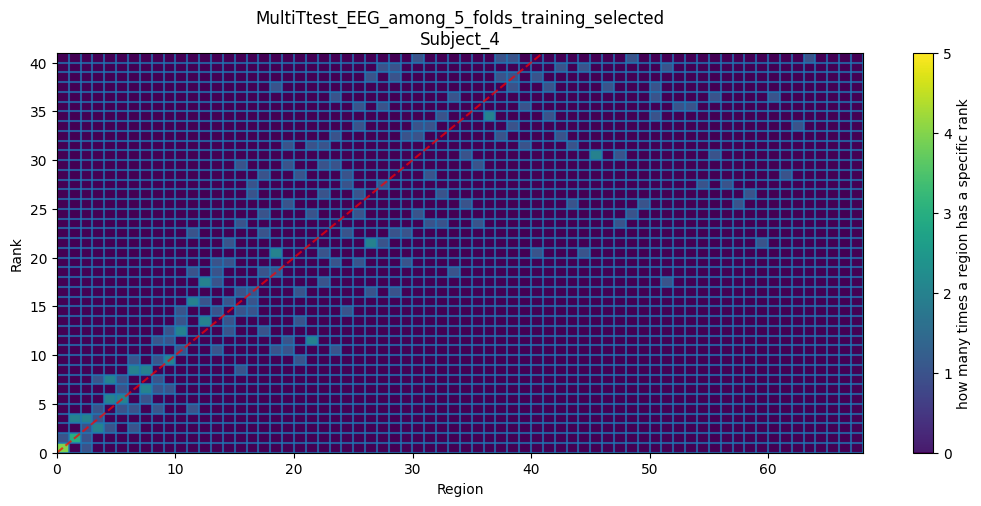

In [ ]:
for subject_idx in range(4,5):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_MultiTtest_EEG_among_5_folds_training_selected.pkl",
                                subject=subject_idx, num_best_selected=41, plot_sorted=True, 
                                figtitle=f"MultiTtest_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                #save_path="../Images/" \
                                #f"Hist2d_region_selection/MultiTtest_EEG_among_5_folds_training_selected_subject_{subject_idx}.png",
                                )


In [ ]:
for subject_index in range(20):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
        "Selected_regions_MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected.pkl",
                                    subject=subject_index, num_best_selected=68, plot_sorted=True, 
                                    figtitle=f"MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected\nSubject_{subject_index}",
                                    #save_path="../Images/" \
                                    #f"Hist2d_region_selection/MultiTtest_on_mean_alpha_beta_EEG_among_5_folds_training_selected_subject_{subject_index}.png",
    )
None

In [ ]:
for subject_idx in range(20):
    plot_hist2d_selected_regions_folds("../Results/RegionSelection/" \
    "Selected_regions_MyCriteria_EEG_among_5_folds_training_selected_freq_8_30.pkl",
                                subject=subject_idx, num_best_selected=68, plot_sorted=True, 
                                figtitle=f"MyCriteria_EEG_among_5_folds_training_selected\nSubject_{subject_idx}",
                                #save_path="../Images/" \
                                #f"Hist2d_region_selection/MyCriteria_EEG_among_5_folds_training_selected_subject_{subject_idx}_freq_8_30.png"
                                )


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
patti = "../Results/RegionSelection/Selected_regions_MultiTtest_EEG_among_5_folds_training_selected.pkl"
Multi_T_test=pd.read_pickle(patti)
Multi_T_test